In [1]:
import os
import sys
import argparse

import seaborn as sns
import matplotlib.pyplot as plt

from data import *
from utils import *
import pandas as pd
from scipy import stats
from datetime import datetime

sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Disentanglement'))
sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Accuracy'))
sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Attack'))

from DCI import compute_dci, report_dci
from IRS import compute_irs_from_multihot_labels, compute_irs
from MIG import compute_mig
from BA import oh_binary_accuracy
from WB import *

In [2]:
parser = argparse.ArgumentParser(description='Gen-RKM Model')

parser.add_argument('--N', type=int, default=10_000, help='Total # of samples')                     # Maybe 10_000
parser.add_argument('--mb_size', type=int, default=128, help='Mini-batch size. See utils.py')
parser.add_argument('--h_dim', type=int, default=24, help='Dim of latent vector')                   # Maybe 16, 32
parser.add_argument('--capacity', type=int, default=32, help='Capacity of network. See utils.py')   # Maybe 16, 48 or 64 if too blurry
parser.add_argument('--x_fdim', type=int, default=48, help='Input x_fdim. See utils.py')            # Maybe 96 or 128
parser.add_argument('--y_fdim', type=int, default=16, help='Input y_fdim. See utils.py')            # Maybe 10, 16, 20, 32
parser.add_argument('--c_accu', type=float, default=25, help='Input weight on recons_error')        # Maybe 10, 25, 50, 100

# Training Settings =============================
parser.add_argument('--lr', type=float, default=1e-4, help='Input learning rate for optimizer')     # Maybe 3e-4, 1e-4, 5e-5
parser.add_argument('--max_epochs', type=int, default=0, help='Input max_epoch for cut-off') # 500
parser.add_argument('--device', type=str, default='cpu', help='Device type: cuda or cpu')
parser.add_argument('--workers', type=int, default=0, help='# of workers for dataloader')
parser.add_argument('--shuffle', type=bool, default=True, help='shuffle dataset: true or false')

opt, _ = parser.parse_known_args()

In [3]:
_, xtest, ipVec_dim, nChannels = get_mnist_dataloader(args=opt)

In [4]:
model = '3V'            # 1V, 2V-IS, 2V-IL, 3V
max_batches = 10
i_val = 10
epsilon = 0.2

In [5]:
def kPCA(X, Y, Z=None, eps=1e-6):
    a = X @ X.T + Y @ Y.T
    B = a.size(0)

    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    a = 0.5 * (a + a.T)  # numerical symmetry
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    evals, evecs = torch.linalg.eigh(a)
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    return evecs[:, :opt.h_dim], evals

In [6]:
def kPCA_SV(X, Y=None, Z=None, eps=1e-6):
    a = X @ X.T
    B = a.size(0)

    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    a = 0.5 * (a + a.T)  # numerical symmetry
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    evals, evecs = torch.linalg.eigh(a)
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    return evecs[:, :opt.h_dim], evals

In [7]:
model_1V = torch.load(f'./out/Final-1V.tar', map_location=opt.device, weights_only=False)
model_2V = torch.load(f'./out/Final.tar', map_location=opt.device, weights_only=False)

In [8]:
# Single View Models
net_im_en_1V = model_1V['net1']
net_im_de_1V = model_1V['net3']

# Dual View Models
net_im_en_2V = model_2V['net1']
net_la_en_2V = model_2V['net2']

net_im_de_2V = model_2V['net3']
net_la_de_2V = model_2V['net4']

In [9]:
net_im_en_1V.eval()
net_im_de_1V.eval()

net_im_en_2V.eval()
net_la_en_2V.eval()
net_im_de_2V.eval()
net_la_de_2V.eval()

Net4(
  (fc1): Linear(in_features=16, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=10, bias=True)
)

In [17]:
all_data_im, all_data_la = [], []
all_adv_data_im, all_adv_data_la = [], []

im_en_1V = []
im_en_2V, la_en_2V = [], []

adv_im_en_1V = []
adv_im_en_2V, adv_la_en_2V = [], []

im_de_1V = []
im_de_2V, la_de_2V = [], []

adv_im_de_1V = []
adv_im_de_2V, adv_la_de_2V = [], []

U_1Vs = []
U_2Vs, V_2Vs = [], []

im_loss_1V = []
im_loss_2V, la_loss_2V = [], []

In [18]:
recon_loss1 = torch.nn.MSELoss()
recon_loss2 = torch.nn.BCEWithLogitsLoss()

In [19]:
FGSM_1V = WB_Attack(net_in1=net_im_en_1V, net_out1=net_im_de_1V, kPCA=kPCA_SV, opt=opt)
FGSM_2V = WB_Attack(net_in1=net_im_en_2V, net_in2=net_la_en_2V, net_out1=net_im_de_2V, net_out2=net_la_de_2V, kPCA=kPCA, opt=opt)

In [20]:
if model == '1V':
    attack = FGSM_1V
else:
    attack = FGSM_2V

In [21]:
adv_images = []

In [22]:
for i, (data_im, data_la) in enumerate(xtest):
    if i >= max_batches:
        break

    data_im, data_la = data_im.to(opt.device), data_la.to(opt.device)

    if model == '1V':
        adv_image, _ = attack.create_adversarial_batch_fgsm(data_im)
    else:
        adv_image, _ = attack.create_adversarial_batch_fgsm(data_im, data_la)

    adv_images.append(adv_image.cpu().detach())

In [23]:
xtest_iter = iter(xtest)

for i in range(max_batches):
    data_im, data_la = next(xtest_iter)
    
    adv_im = adv_images[i].to(opt.device)
   
    all_data_im.append(data_im.cpu())
    all_data_la.append(data_la.cpu())

    all_adv_data_im.append(adv_im.cpu())
    all_adv_data_la.append(data_la.cpu())

    with torch.no_grad():
        im_en_1V.append(net_im_en_1V(data_im.cpu()))
        im_en_2V.append(net_im_en_2V(data_im.cpu()))
        la_en_2V.append(net_la_en_2V(data_la.cpu()))

        adv_im_en_1V.append(net_im_en_1V(adv_im.cpu()))
        adv_im_en_2V.append(net_im_en_2V(adv_im.cpu()))
        adv_la_en_2V.append(net_la_en_2V(data_la.cpu()))

In [25]:
all_data_im = torch.cat(all_data_im, dim=0)
all_data_la = torch.cat(all_data_la, dim=0)

all_adv_data_im = torch.cat(all_adv_data_im, dim=0)
all_adv_data_la = torch.cat(all_adv_data_la, dim=0)

im_en_1V = torch.cat(im_en_1V, dim=0)
im_en_2V = torch.cat(im_en_2V, dim=0)
la_en_2V = torch.cat(la_en_2V, dim=0)

adv_im_en_1V = torch.cat(adv_im_en_1V, dim=0)
adv_im_en_2V = torch.cat(adv_im_en_2V, dim=0)
adv_la_en_2V = torch.cat(adv_la_en_2V, dim=0)

In [26]:
with torch.no_grad():
    for i in range(i_val):
        start, stop = i * 100, (i + 1) * 100

        h_1V, _ = kPCA_SV(im_en_1V[start:stop])
        h_2V, _ = kPCA(im_en_2V[start:stop], la_en_2V[start:stop])

        adv_h_1V, _ = kPCA_SV(adv_im_en_1V[start:stop])
        adv_h_2V, _ = kPCA(adv_im_en_2V[start:stop], adv_la_en_2V[start:stop])

        U_1V = im_en_1V[start:stop].T @ h_1V
        U_2V = im_en_2V[start:stop].T @ h_2V
        V_2V = la_en_2V[start:stop].T @ h_2V

        im_1V_tilde = net_im_de_1V(h_1V @ U_1V.T)
        im_2V_tilde = net_im_de_2V(h_2V @ U_2V.T)
        la_2V_tilde = net_la_de_2V(h_2V @ V_2V.T)

        adv_im_1V_tilde = net_im_de_1V(adv_h_1V @ U_1V.T)
        adv_im_2V_tilde = net_im_de_2V(adv_h_2V @ U_2V.T)
        adv_la_2V_tilde = net_la_de_2V(adv_h_2V @ V_2V.T)

        im_de_1V.append(im_1V_tilde.cpu())
        im_de_2V.append(im_2V_tilde.cpu())
        la_de_2V.append(la_2V_tilde.cpu())

        adv_im_de_1V.append(adv_im_1V_tilde.cpu())
        adv_im_de_2V.append(adv_im_2V_tilde.cpu())
        adv_la_de_2V.append(adv_la_2V_tilde.cpu())        

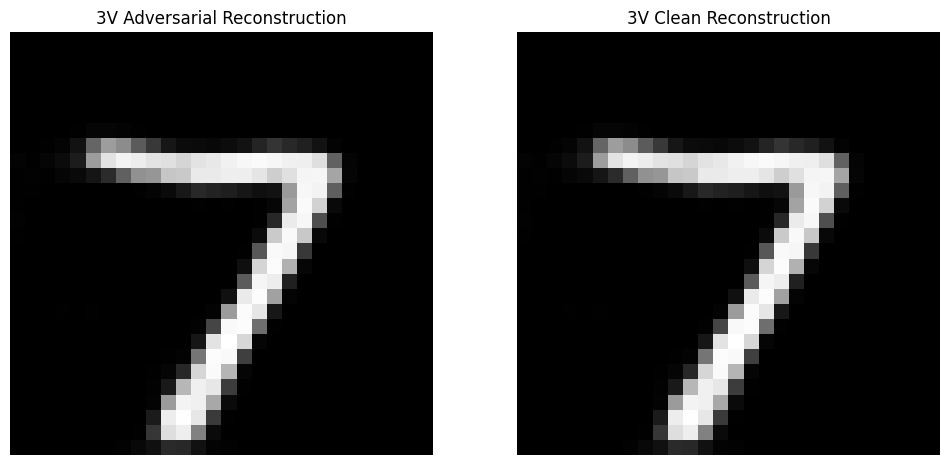

In [29]:
# Plot 3V images encoding vs decoding adv and non adv
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(adv_im_de_2V[0][0].permute(1, 2, 0), cmap='gray')
plt.title('3V Adversarial Reconstruction')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(im_de_2V[0][0].permute(1, 2, 0), cmap='gray')
plt.title('3V Clean Reconstruction')
plt.axis('off')
plt.show()

## Attack Loss

In [30]:
clean_losses_im_1V = []
clean_losses_im_2V, clean_losses_la_2V = [], []

adv_losses_im_1V = []
adv_losses_im_2V, adv_losses_la_2V = [], []

In [31]:
for i in range(i_val):
    start, stop = i * 100, (i + 1) * 100

    batch_im = all_data_im[start:stop]
    adv_batch_im = all_adv_data_im[start:stop]

    batch_la = all_data_la[start:stop]
    adv_batch_la = all_adv_data_la[start:stop]

    clean_losses_im_1V.append(recon_loss1(im_de_1V[i], batch_im).item())
    clean_losses_im_2V.append(recon_loss1(im_de_2V[i], batch_im).item())
    clean_losses_la_2V.append(recon_loss2(la_de_2V[i], batch_la).item())

    adv_losses_im_1V.append(recon_loss1(adv_im_de_1V[i], adv_batch_im).item())
    adv_losses_im_2V.append(recon_loss1(adv_im_de_2V[i], adv_batch_im).item())
    adv_losses_la_2V.append(recon_loss2(adv_la_de_2V[i], adv_batch_la).item())

In [32]:
models = ['1V', '2V']

clean_im_losses = [clean_losses_im_1V, clean_losses_im_2V]
adv_im_losses = [adv_losses_im_1V, adv_losses_im_2V]

clean_la_losses = [None, clean_losses_la_2V]
adv_la_losses = [None, adv_losses_la_2V]

In [ ]:
# for i, x in enumerate(models):
#     r = pd.DataFrame({
#         'model': [x] * i_val,

#         'Clean_IM_Loss': clean_im_losses[i],
#         'FGSM_IM_Loss': adv_im_losses[i],
#         'Clean_LA_Loss': clean_la_losses[i] if clean_la_losses[i] is not None else [None] * i_val,
#         'FGSM_LA_Loss': adv_la_losses[i] if adv_la_losses[i] is not None else [None] * i_val
#     })

#     results_file = 'Attack-B-Results.csv'
#     if os.path.exists(results_file):
#         r.to_csv(results_file, mode='a', header=False, index=False)
#     else:
#         r.to_csv(results_file, index=False)